#Data Cleaning Project

## 1. Import Libraries

In [11]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt  


## 2. Load Dataset

In [12]:
df = pd.read_excel("../data/raw/First Dataset.xlsx")


In [ ]:
df.head()

# 3.Dataset Overview

In [ ]:
df.tail()

In [15]:
df.shape


(61, 17)

In [ ]:
df.info()

In [ ]:
df.describe(include="all")

In [ ]:
df.columns

In [ ]:
df.dtypes

In [ ]:
df.memory_usage(deep=True)

In [ ]:
df.dropna()

# Fill missing age values before converting to integer


In [ ]:
df["age"] = df["age"].fillna(df["age"].median())
df["age"] = df["age"].astype(int)

# Verify data types


In [ ]:
df.dtypes

# 7.Data Validation

# Missing Values

In [ ]:
df.isnull().sum()

In [ ]:
(df.isnull().sum()/len(df))*100

In [ ]:
df[df.isnull().any(axis=1)]

In [ ]:
df["age"]= df["age"].fillna(df["age"].median())

In [ ]:
df["total_spending"] = df["total_spending"].fillna(
    df["purchase_count"] * df["avg_order_value"]
)

# 5. Duplicate Records

In [ ]:
df.duplicated().sum()

In [ ]:
df[df.duplicated()]

In [ ]:
df = df.drop_duplicates()

# 6. Data Types

In [ ]:
df.dtypes

In [71]:
df["signup_date"] = pd.to_datetime(df["signup_date"])


## Data Type Conversion

Convert columns to their appropriate data to enable accurate analysis and data processing.

# Convert signup_date to datetime


# 8. Invalid Values

In [33]:
df[df["age"]< 0]

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score


In [ ]:
print("Negative Purchase Count")
display(df[df["purchase_count"] < 0])

print("Negative Average Order Value")
display(df[df["avg_order_value"] < 0])

print("Negative Total Spending")
display(df[df["total_spending"] < 0])

print("Negative Last Purchase Days")
display(df[df["last_purchase_days"] < 0])

In [ ]:
numeric_columns = [
    "age",
    "purchase_count",
    "avg_order_value",
    "total_spending",
    "last_purchase_days",
    "returned_items"
]

for col in numeric_columns:
    negative = df[df[col] < 0]
    print(f"{col}: {len(negative)} negative values")

# 9. Range Validation

# 10. Outlier Detection

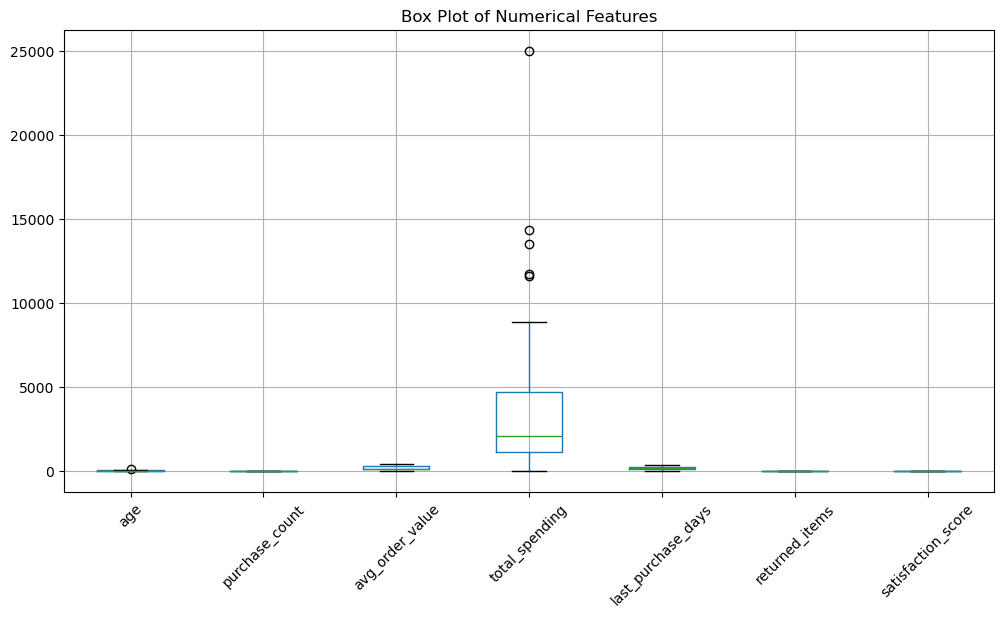

In [40]:
import matplotlib.pyplot as plt

numeric_columns = [
    "age",
    "purchase_count",
    "avg_order_value",
    "total_spending",
    "last_purchase_days",
    "returned_items",
    "satisfaction_score"
]

plt.figure(figsize=(12, 6))
df[numeric_columns].boxplot()

plt.xticks(rotation=45)
plt.title("Box Plot of Numerical Features")
plt.show()

In [43]:
numeric_columns = [
    "age",
    "purchase_count",
    "avg_order_value",
    "total_spending",
    "last_purchase_days",
    "returned_items",
    "satisfaction_score"
]

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"\n{col}")
    print(f"Q1 = {Q1}")
    print(f"Q3 = {Q3}")
    print(f"IQR = {IQR}")
    print(f"Outliers = {len(outliers)}")


age
Q1 = 31.75
Q3 = 58.0
IQR = 26.25
Outliers = 1

purchase_count
Q1 = 10.75
Q3 = 24.5
IQR = 13.75
Outliers = 0

avg_order_value
Q1 = 108.1375
Q3 = 324.1075
IQR = 215.97000000000003
Outliers = 0

total_spending
Q1 = 1167.035
Q3 = 4692.15
IQR = 3525.115
Outliers = 5

last_purchase_days
Q1 = 134.25
Q3 = 273.75
IQR = 139.5
Outliers = 0

returned_items
Q1 = 2.0
Q3 = 7.0
IQR = 5.0
Outliers = 0

satisfaction_score
Q1 = 2.0
Q3 = 4.0
IQR = 2.0
Outliers = 0


In [45]:
report = []

text_columns = [
    "first_name",
    "gender",
    "city",
    "province",
    "membership_tier",
    "payment_method",
    "device",
    "discount_used"
]

for col in text_columns:
    extra_spaces = (df[col] != df[col].str.strip()).sum()

    report.append({
        "Column": col,
        "Extra Spaces": extra_spaces
    })

space_report = pd.DataFrame(report)

space_report

,Column,Extra Spaces
0,first_name,0
1,gender,0
2,city,0
3,province,0
4,membership_tier,0
5,payment_method,0
6,device,0
7,discount_used,0


# 11. Text Cleaning

In [46]:
text_columns = [
    "first_name",
    "city",
    "province",
    "membership_tier",
    "payment_method",
    "device"
]

for col in text_columns:
    inconsistent = df[df[col] != df[col].str.title()]

    print(f"\n{col}")
    print("Inconsistent values:", len(inconsistent))

    if len(inconsistent) > 0:
        display(inconsistent[[col]])


first_name
Inconsistent values: 0

city
Inconsistent values: 0

province
Inconsistent values: 0

membership_tier
Inconsistent values: 15


,membership_tier
0,VIP
6,VIP
7,VIP
13,VIP
16,VIP
17,VIP
24,VIP
29,VIP
32,VIP
33,VIP



payment_method
Inconsistent values: 0

device
Inconsistent values: 18


,device
2,iPhone
6,iPhone
7,iPhone
11,iPhone
16,iPhone
18,iPhone
25,iPhone
35,iPhone
38,iPhone
42,iPhone


# 12. Category Consistency

# 13. Column Name Cleaning

# 14. Special Characters

# 15.Unique Values

In [47]:
df["city"].unique()

array(['Karaj', 'Tehran', 'Shiraz', 'Mashhad', 'Isfahan', 'Rasht',
       'Tabriz', 'Ahvaz'], dtype=object)

In [48]:
df["city"].value_counts()

city
Tabriz     12
Mashhad    11
Ahvaz       8
Karaj       7
Tehran      6
Shiraz      6
Isfahan     5
Rasht       5
Name: count, dtype: int64

# 16. Business Rules Validation

# 17. Logical Consistency

# 18. Cross Column Validation

In this step, relations between related columns are validated to detect logical inconsistencies in the dataset.

print("======Cross Column Validation =======")

# Age should be between 18 and 100

In [49]:
invalid_age = df[(df["age"] < 18) | (df["age"] > 100)]
print(f"Invalid Age: {len(invalid_age)}")

Invalid Age: 1


#  Purchase count should not negative

In [50]:
invalid_purchase = df[df["purchase_count"] < 0]
print(f"Negative Purchase Count: {len(invalid_purchase)}")

Negative Purchase Count: 0


# average order value should not be negative

In [51]:
invalid_avg_order = df[df["avg_order_value"] < 0]
print(f"Negative Average Order Value: {len(invalid_avg_order)}")

Negative Average Order Value: 0


# Total spending should not be negative


In [52]:
invalid_spending = df[df["total_spending"] < 0]
print(f"Negative Total Spending: {len(invalid_spending)}")

Negative Total Spending: 0


# Last purchase days should not be negative


In [53]:
invalid_last_purchase = df[df["last_purchase_days"] < 0]
print(f"Negative Last Purchase Days: {len(invalid_last_purchase)}")

Negative Last Purchase Days: 0


# Satisfaction score should be between 1 and 5


In [54]:
invalid_score = df[
    (df["satisfaction_score"] < 1) |
    (df["satisfaction_score"] > 5)
]
print(f"Invalid Satisfaction Score: {len(invalid_score)}")

Invalid Satisfaction Score: 0


In [55]:
expected_total = df["purchase_count"] * df["avg_order_value"]

difference = abs(expected_total - df["total_spending"])

inconsistent = df[difference > 1]

print("Inconsistent Spending Records:", len(inconsistent))

Inconsistent Spending Records: 1


# 19. Formatting Consistency

In this step, categorical columns are checked for formatting consistency, including extra spaces, letter case, and inconsistent values.

In [56]:
categorical_columns = [
    "first_name",
    "gender",
    "province",
    "city",
    "membership_tier",
    "payment_method",
    "device",
    ]

for col in categorical_columns:
    print(f"\n{col}")
    print(df[col].value_counts())


first_name
first_name
Sina      8
Neda      8
Reza      7
Kimia     7
Amir      6
Ali       6
Parsa     4
Arash     4
Maryam    4
Mina      3
Zahra     2
Sara      1
Name: count, dtype: int64

gender
gender
F    35
M    25
Name: count, dtype: int64

province
province
East Azerbaijan    12
Khorasan           11
Khuzestan           8
Alborz              7
Tehran              6
Fars                6
Isfahan             5
Gilan               5
Name: count, dtype: int64

city
city
Tabriz     12
Mashhad    11
Ahvaz       8
Karaj       7
Tehran      6
Shiraz      6
Isfahan     5
Rasht       5
Name: count, dtype: int64

membership_tier
membership_tier
Gold      19
Bronze    18
VIP       15
Silver     8
Name: count, dtype: int64

payment_method
payment_method
Online Wallet    23
Cash             19
Card             18
Name: count, dtype: int64

device
device
Android    22
Web        20
iPhone     18
Name: count, dtype: int64


# 20. Data Distribution

The section analyzes the distribution of numerical variables to identify unusual and potential outliers.

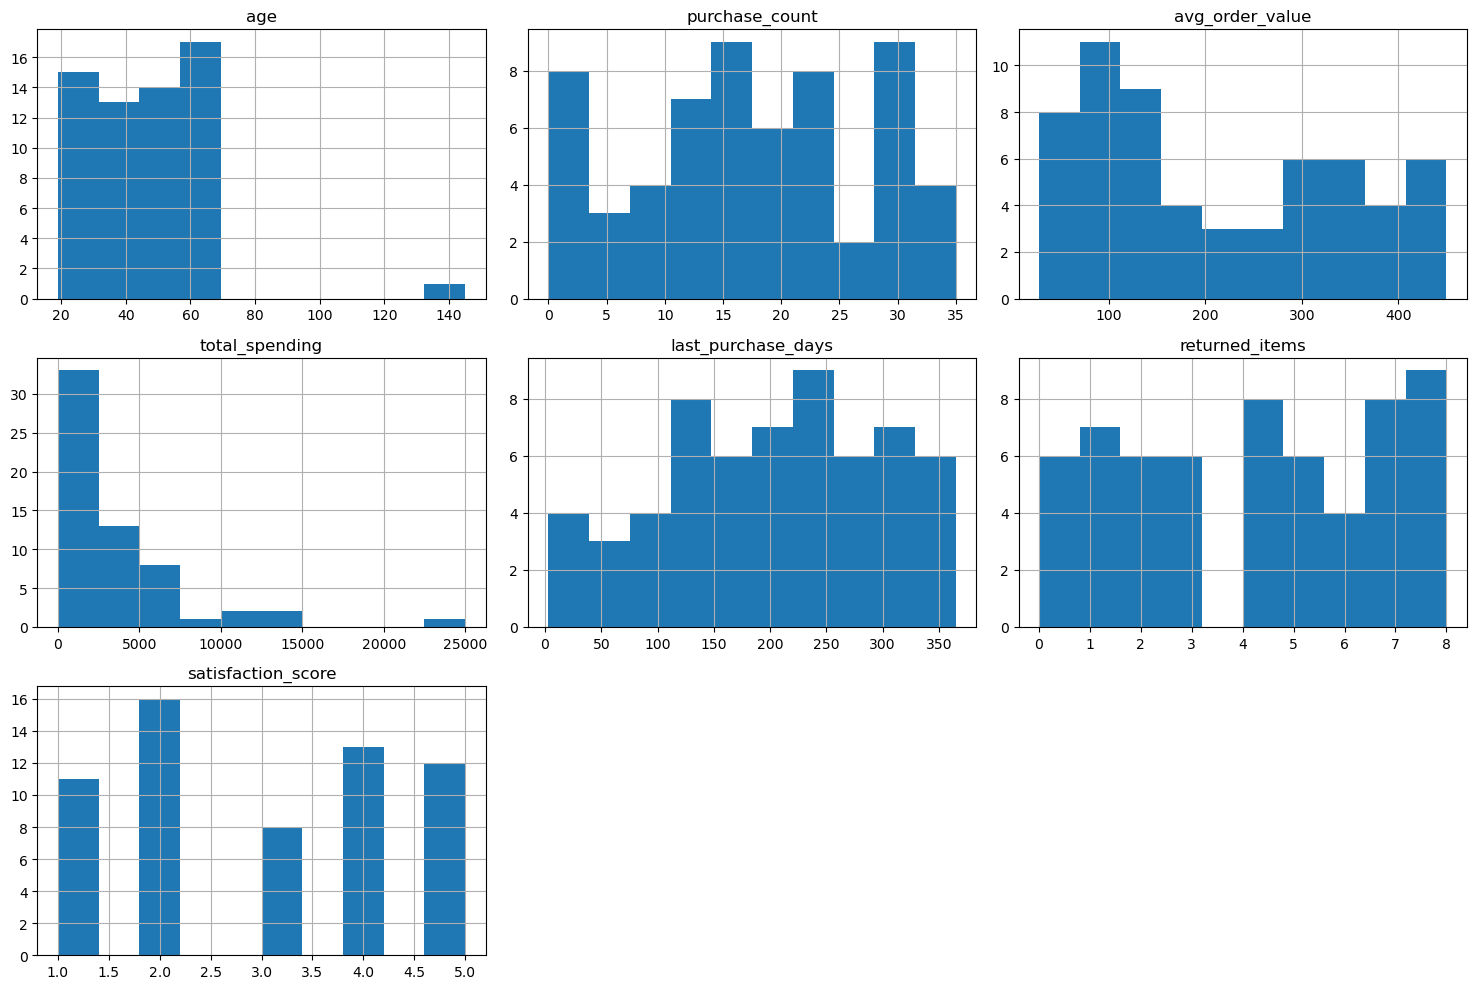

In [59]:
import matplotlib.pyplot as plt
numeric_columns = [
    "age",
    "purchase_count",
    "avg_order_value",
    "total_spending",
    "last_purchase_days",
    "returned_items",
    "satisfaction_score",
]

df[numeric_columns].hist(figsize=(15, 10))

plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

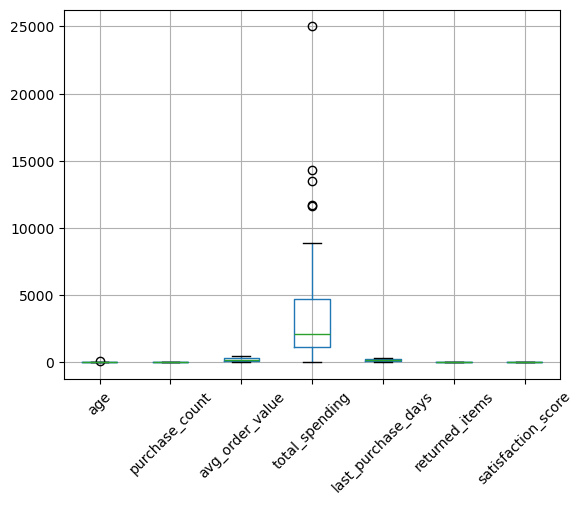

In [64]:
plt.Figure(figsize=(12,6))
df[numeric_columns].boxplot()

plt.xticks(rotation=45)
plt.show

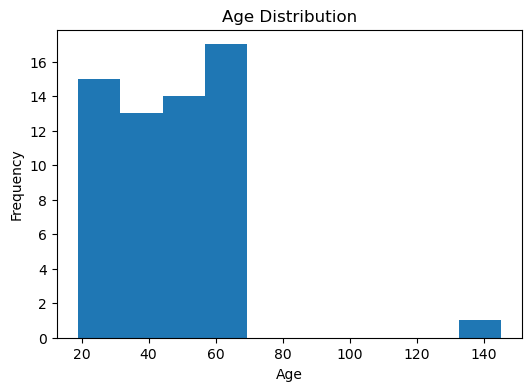

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.hist(df["age"])

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

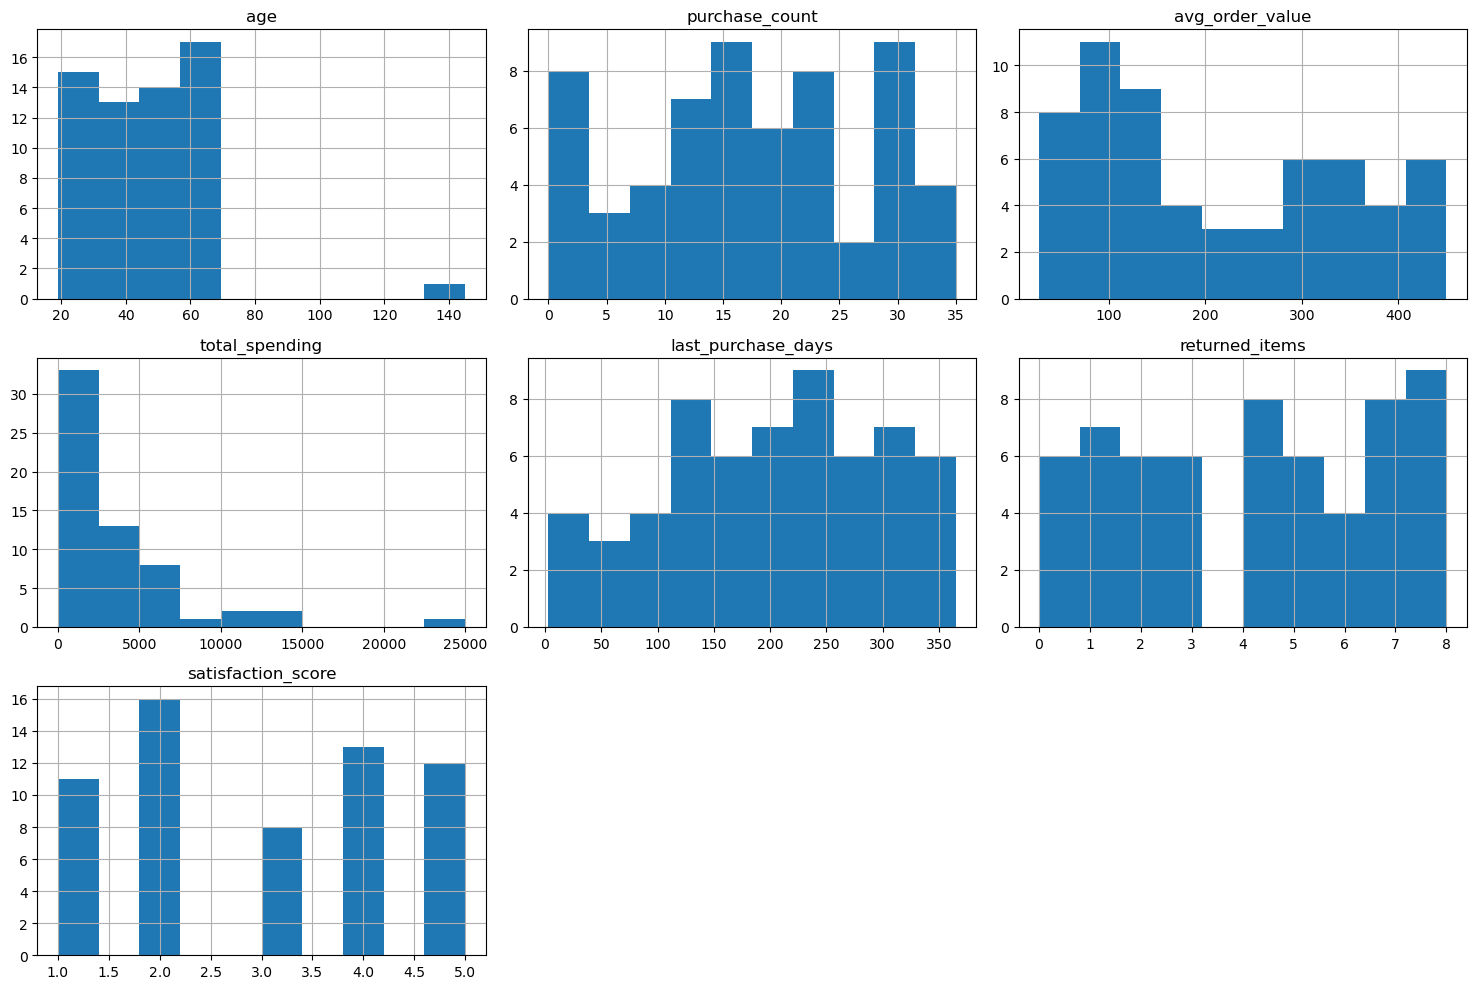

In [ ]:
import matplotlib.pyplot as plt
numeric_columns = [
    "age",
    "purchase_count",
    "avg_order_value",
    "total_spending",
    "last_purchase_days",
    "returned_items",
    "satisfaction_score",
]

df[numeric_columns].hist(figsize=(15, 10))

plt.tight_layout()
plt.show()

# 21. Correlation

In [69]:
numeric_columns = [
    "age",
    "purchase_count",
    "avg_order_value",
    "total_spending",
    "last_purchase_days",
    "returned_items",
    "satisfaction_score"
]

df[numeric_columns].corr()

,age,purchase_count,avg_order_value,total_spending,last_purchase_days,returned_items,satisfaction_score
age,1.000000,0.198999,0.256194,0.336787,0.022004,0.077606,-0.202196
purchase_count,0.198999,1.000000,-0.260207,0.510486,-0.122845,0.014798,0.085575
avg_order_value,0.256194,-0.260207,1.000000,0.352781,0.064695,0.161575,-0.160812
total_spending,0.336787,0.510486,0.352781,1.000000,0.085616,0.064404,0.022710
last_purchase_days,0.022004,-0.122845,0.064695,0.085616,1.000000,-0.000555,-0.291830
returned_items,0.077606,0.014798,0.161575,0.064404,-0.000555,1.000000,-0.281440
satisfaction_score,-0.202196,0.085575,-0.160812,0.022710,-0.291830,-0.281440,1.000000


# 22. Final Validation

# 23. Save Clean Dataset

In [ ]:
df.to_excel()

# 24. Data Cleaning Summary